<a href="https://colab.research.google.com/github/juanselles/book/blob/main/9_Customer_Segmentation_KMeans_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primeros registros de clientes:
        Edad  Ingresos_K  Puntuacion_Gasto
0  56.688017  160.534122        124.540819
1   3.404631  236.551630         75.505605
2  81.368172  106.114404        247.828935
3  29.218050  249.827460        112.504625
4  72.698996  247.412438        145.148409


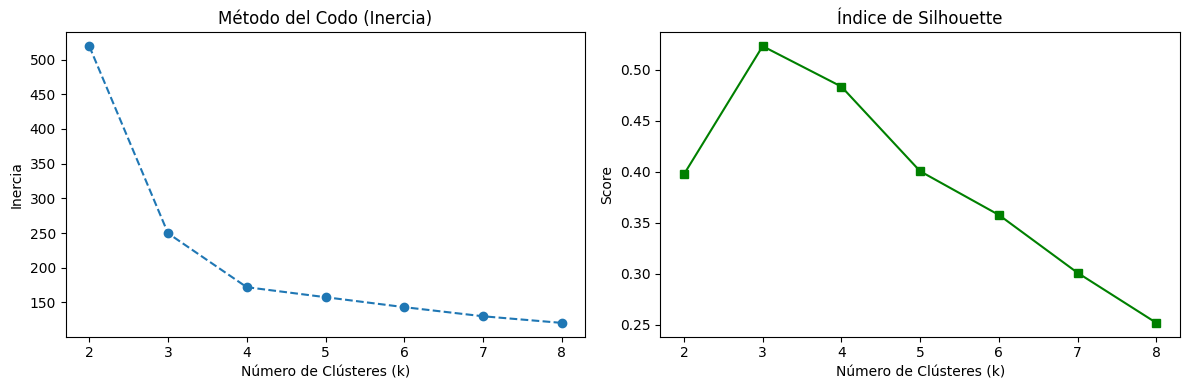

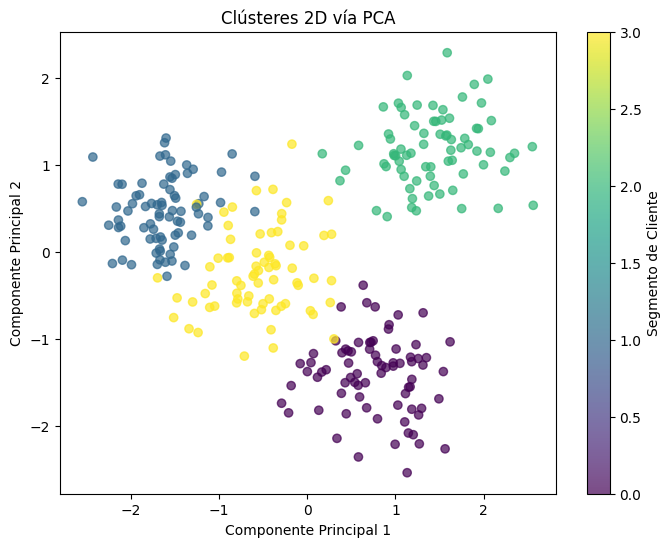

In [3]:
# ==============================================================================
# CAPÍTULO 9: APRENDIZAJE NO SUPERVISADO - CASO PRÁCTICO
# Segmentación de clientes utilizando K-Means y PCA
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

# 1. GENERACIÓN DE DATOS SINTÉTICOS (Simulando una base de datos de marketing)
# Creamos 300 clientes divididos naturalmente en 4 grupos con 3 características:
# Edad, Ingresos Anuales (en miles de €) y Puntuación de Gasto (1-100)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.5, n_features=3, random_state=42)

# Ajustamos las escalas para simular los rangos reales
X[:, 0] = np.abs(X[:, 0] * 10 + 40)   # Edad (aprox. entre 20 y 70 años)
X[:, 1] = np.abs(X[:, 1] * 20 + 50)   # Ingresos (aprox. entre 30k y 120k €)
X[:, 2] = np.abs(X[:, 2] * 15 + 50)   # Gasto (aprox. entre 10 y 90)

df_clientes = pd.DataFrame(X, columns=['Edad', 'Ingresos_K', 'Puntuacion_Gasto'])
print("Primeros registros de clientes:")
print(df_clientes.head())

# ==============================================================================
# 2. EL PASO CRÍTICO: ESCALADO DE CARACTERÍSTICAS
# Tal y como se explica en el libro, si no escalamos, los 'Ingresos'
# dominarán el cálculo de la distancia euclidiana.
# ==============================================================================
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_clientes)

# ==============================================================================
# 3. BÚSQUEDA DEL NÚMERO ÓPTIMO DE CLÚSTERES (ELBOW & SILHOUETTE)
# ==============================================================================
inercia = []
valores_silhouette = []
rango_k = range(2, 9)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    etiquetas_temp = kmeans_temp.fit_predict(X_escalado)

    inercia.append(kmeans_temp.inertia_)
    valores_silhouette.append(silhouette_score(X_escalado, etiquetas_temp))

# Visualización conjunta de ambas métricas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rango_k, inercia, marker='o', linestyle='--')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia')

ax2.plot(rango_k, valores_silhouette, marker='s', color='green', linestyle='-')
ax2.set_title('Índice de Silhouette')
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. ENTRENAMIENTO DEL MODELO FINAL (Observamos que k=4 es el óptimo)
# ==============================================================================
modelo_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
etiquetas_finales = modelo_final.fit_predict(X_escalado)
df_clientes['Segmento'] = etiquetas_finales

# ==============================================================================
# 5. REDUCCIÓN DE DIMENSIONALIDAD (PCA) PARA VISUALIZACIÓN EN 2D
# Tenemos 3 variables, reducimos a 2 para poder crear el gráfico
# ==============================================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clientes['Segmento'], cmap='viridis', alpha=0.7)
plt.title('Clústeres 2D vía PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Segmento de Cliente')
plt.show()